This ensures that our system suitably describes a plasma such that Debye shielding can take place.

In [21]:
import numpy as np
import math

def validateDomain(dx, dy, dz, ne, kT):
  eps0 = 8.854e-12 #in Farads per meter
  qe = -1.602e-19 #in Coulombs
  lamD = math.sqrt((eps0*kT)/(ne*qe**2)) #Debye length

  return max(dx, dy, dz) < lamD

Prints out values for charge, particle number, total energy, and momentum for the system, meant to serve as a check as to conserved quantities.

In [22]:
import numpy as np

def checkConservationLaws(eps0, m_e, m_i, dx, dy, dz, pxe, pxi, vxe, vye, vze, vxi, vyi, vzi, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z):
  #Conservation of charge check
  print("Conservation of Charge")
  total_charge = np.sum(rho)*dx*dy*dz
  print(total_charge)

  #Conservation of particle number check
  print("Conservation of Particle Number")
  print(len(pxe))
  print(len(pxi))

  #Conservation of momentum check
  print("Conservation of Momentum")
  Px = m_e*np.sum(vxe) + m_i*np.sum(vxi)
  Py = m_e*np.sum(vye) + m_i*np.sum(vyi)
  Pz = m_e*np.sum(vze) + m_i*np.sum(vzi)
  print(Px)
  print(Py)
  print(Pz)

  #Conservation of energy check
  print("Conservation of Energy")
  KE_e = 0.5*m_e*np.sum(vxe**2 + vye**2 + vze**2)
  KE_i = 0.5*m_i*np.sum(vxi**2 + vyi**2 + vzi**2)
  PE = (0.5*eps0*np.sum(EFieldGrid_x**2 + EFieldGrid_y**2 + EFieldGrid_z**2)*dx*dy*dz)
  print(KE_e + KE_i + PE)

Animate E-Field for the gridpoints and animate particle trajectories.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z):
  if t % 10 == 0:
    xGrid = np.linspace(0, L_x, nx)
    yGrid = np.linspace(0, L_y, ny)
    zGrid = np.linspace(0, L_z, nz)

    X, Y, Z = np.meshgrid(xGrid, yGrid, zGrid, indexing='ij')
    step = 3

    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')

    ax.quiver(X[::step,::step,::step], Y[::step,::step,::step], Z[::step,::step,::step], EFieldGrid_x[::step,::step,::step], EFieldGrid_y[::step,::step,::step], EFieldGrid_z[::step,::step,::step], length=0.01, normalize=True)

    num_show = 2  # don't plot all 1000 particles

    for p in range(num_show):
        ax.plot(np.array(electron_traj_x)[:,p], np.array(electron_traj_y)[:,p], np.array(electron_traj_z)[:,p], linewidth=1)

    for p in range(num_show):
        ax.plot(np.array(ion_traj_x)[:,p], np.array(ion_traj_y)[:,p], np.array(ion_traj_z)[:,p], linewidth=1)

    ax.set_xlim(0, L_x)
    ax.set_ylim(0, L_y)
    ax.set_zlim(0, L_z)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.set_title(f"Electric Field at timestep {t}")
    plt.show()


This protects our boundary conditions and ensures that particles at the boundaries are reflected internally.

In [24]:
import numpy as np

def boundaryCondition(L_x, L_y, L_z, px, py, pz, vx, vy, vz, Num):
  for p in range(Num):
    # x-direction reflection
    while px[p] < 0 or px[p] > L_x:
        if px[p] < 0:
            px[p] = -px[p]
            vx[p] *= -1

        elif px[p] > L_x:
            px[p] = 2*L_x - px[p]
            vx[p] *= -1

    # y-direction reflection
    while py[p] < 0 or py[p] > L_y:
        if py[p] < 0:
            py[p] = -py[p]
            vy[p] *= -1

        elif py[p] > L_y:
            py[p] = 2*L_y - py[p]
            vy[p] *= -1

    # z-direction reflection
    while pz[p] < 0 or pz[p] > L_z:
        if pz[p] < 0:
            pz[p] = -pz[p]
            vz[p] *= -1

        elif pz[p] > L_z:
            pz[p] = 2*L_z - pz[p]
            vz[p] *= -1

  return px, py, pz, vx, vy, vz

This constructs our charge density via cloud-in-cell weighting.

In [25]:
import numpy as np
import math

def findRhoGrid(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, num_e, num_i, rho):
  rho.fill(0)
  qe = -1.602e-19 #in Coulombs
  qi = 1.602e-19

  for p in range(num_e):
    x = pxe[p]
    y = pye[p]
    z = pze[p]
    i = min(int(x/dx), nx - 2)
    j = min(int(y/dy), ny - 2)
    k = min(int(z/dz), nz - 2)

    sx = (x - i*dx)/dx
    sy = (y - j*dy)/dy
    sz = (z - k*dz)/dz

    w000 = (1-sx)*(1-sy)*(1-sz)
    w100 = sx*(1-sy)*(1-sz)
    w010 = (1-sx)*sy*(1-sz)
    w110 = sx*sy*(1-sz)
    w001 = (1-sx)*(1-sy)*sz
    w101 = sx*(1-sy)*sz
    w011 = (1-sx)*sy*sz
    w111 = sx*sy*sz

    rho[i  ,j  ,k  ] += qe*w000
    rho[i+1,j  ,k  ] += qe*w100
    rho[i  ,j+1,k  ] += qe*w010
    rho[i+1,j+1,k  ] += qe*w110
    rho[i  ,j  ,k+1] += qe*w001
    rho[i+1,j  ,k+1] += qe*w101
    rho[i  ,j+1,k+1] += qe*w011
    rho[i+1,j+1,k+1] += qe*w111

  for p in range(num_i):
    x = pxi[p]
    y = pyi[p]
    z = pzi[p]
    i = min(int(x/dx), nx - 2)
    j = min(int(y/dy), ny - 2)
    k = min(int(z/dz), nz - 2)

    sx = (x - i*dx)/dx
    sy = (y - j*dy)/dy
    sz = (z - k*dz)/dz

    w000 = (1-sx)*(1-sy)*(1-sz)
    w100 = sx*(1-sy)*(1-sz)
    w010 = (1-sx)*sy*(1-sz)
    w110 = sx*sy*(1-sz)
    w001 = (1-sx)*(1-sy)*sz
    w101 = sx*(1-sy)*sz
    w011 = (1-sx)*sy*sz
    w111 = sx*sy*sz

    rho[i  ,j  ,k  ] += qi*w000
    rho[i+1,j  ,k  ] += qi*w100
    rho[i  ,j+1,k  ] += qi*w010
    rho[i+1,j+1,k  ] += qi*w110
    rho[i  ,j  ,k+1] += qi*w001
    rho[i+1,j  ,k+1] += qi*w101
    rho[i  ,j+1,k+1] += qi*w011
    rho[i+1,j+1,k+1] += qi*w111
  rho /= dx*dy*dz
  return rho


We have three constructions for phi (relative to the grid points) using three methods:

-Method 1: Jacobi

-Method 2: Gauss-Seidel

-Method 3: Successive Over-relaxation (SOR)

In [26]:
import numpy as np
import math

def findPhiGridMethod1(dx, dy, dz, nx, ny, nz, rho, max_iter, tolerance, phi):
  eps0 = 8.854e-12 #in Farads per meter
  phi_old = phi.copy()
  phi_new = phi.copy()

  for l in range(max_iter):
    max_change = 0
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            for k in range(1, nz-1):
              comparePhi = phi_new[i,j,k]
              phi_new[i,j,k] = (rho[i,j,k]/eps0 + (phi_old[i-1,j,k] + phi_old[i+1,j,k])/dx**2 + (phi_old[i,j-1,k] + phi_old[i,j+1,k])/dy**2 + (phi_old[i,j,k-1] + phi_old[i,j,k+1])/dz**2)/(2/dx**2 + 2/dy**2 + 2/dz**2)
              change = abs(phi_new[i,j,k] - comparePhi)
              max_change = max(max_change, change)
    if max_change < tolerance:
      break
    phi_old, phi_new = phi_new, phi_old
  return phi_old

def findPhiGridMethod2(dx, dy, dz, nx, ny, nz, rho,
                       max_iter, tolerance, phi):

    eps0 = 8.854e-12  # F/m

    for l in range(max_iter):

        max_change = 0.0

        for i in range(1, nx-1):
            for j in range(1, ny-1):
                for k in range(1, nz-1):

                    oldPhi = phi[i,j,k]

                    phi[i,j,k] = (
                        rho[i,j,k]/eps0
                        + (phi[i-1,j,k] + phi[i+1,j,k])/dx**2
                        + (phi[i,j-1,k] + phi[i,j+1,k])/dy**2
                        + (phi[i,j,k-1] + phi[i,j,k+1])/dz**2
                    ) / (
                        2/dx**2 + 2/dy**2 + 2/dz**2
                    )

                    change = abs(phi[i,j,k] - oldPhi)

                    if change > max_change:
                        max_change = change
        if max_change < tolerance:
            return phi
    return phi

def findPhiGridMethod3(dx, dy, dz, nx, ny, nz, rho, max_iter, tolerance, phi, omega):
  eps0 = 8.854e-12 #in Farads per meter

  max_change = 0

  for l in range(max_iter):
    max_change = 0
    for i in range(1, nx-1):
        for j in range(1, ny-1):
            for k in range(1, nz-1):
              oldPhi = phi[i,j,k]
              phiGS =  (rho[i,j,k]/eps0 + (phi[i-1,j,k] + phi[i+1,j,k])/dx**2 + (phi[i,j-1,k] + phi[i,j+1,k])/dy**2 + (phi[i,j,k-1] + phi[i,j,k+1])/dz**2)/(2/dx**2 + 2/dy**2 + 2/dz**2)
              phi[i,j,k] = (1-omega)*oldPhi + omega*phiGS
              change = abs(phi[i,j,k] - oldPhi)
              max_change = max(max_change, change)
    if max_change < tolerance:
      break
  return phi


Once \phi is found, the E-field for the grid points follows suit using centered finite differences formula.

In [27]:
import numpy as np

def findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phi, EGrid_x, EGrid_y, EGrid_z):
  for i in range(1, nx-1):
        for j in range(1, ny-1):
            for k in range(1, nz-1):

                EGrid_x[i,j,k] = -(phi[i+1,j,k] - phi[i-1,j,k])/(2*dx)

                EGrid_y[i,j,k] = -(phi[i,j+1,k] - phi[i,j-1,k])/(2*dy)

                EGrid_z[i,j,k] = -(phi[i,j,k+1] - phi[i,j,k-1])/(2*dz)

  return EGrid_x, EGrid_y, EGrid_z

Once we have the E-field for gridpoints, we can basically do a backwards implementation of cloud-in-cell weighting.

In [28]:
import numpy as np

def findElectricFieldParticles(L_x, L_y, L_z, dx, dy, dz, pxi, pyi, pzi, pxe, pye, pze, EGrid_x, EGrid_y, EGrid_z, Num_e, Num_i, Epx_e, Epy_e, Epz_e, Epx_i, Epy_i, Epz_i):
  for p in range(Num_e):
    x = pxe[p] % L_x
    y = pye[p] % L_y
    z = pze[p] % L_z
    i = min(int(x/dx), nx - 2)
    j = min(int(y/dy), ny - 2)
    k = min(int(z/dz), nz - 2)

    sx = (x - i*dx)/dx
    sy = (y - j*dy)/dy
    sz = (z - k*dz)/dz

    w000 = (1-sx)*(1-sy)*(1-sz)
    w100 = sx*(1-sy)*(1-sz)
    w010 = (1-sx)*sy*(1-sz)
    w110 = sx*sy*(1-sz)
    w001 = (1-sx)*(1-sy)*sz
    w101 = sx*(1-sy)*sz
    w011 = (1-sx)*sy*sz
    w111 = sx*sy*sz

    Epx_e[p] = (w000*EGrid_x[i,j,k] + w100*EGrid_x[i+1,j,k] + w010*EGrid_x[i,j+1,k] + w110*EGrid_x[i+1,j+1,k] + w001*EGrid_x[i,j,k+1] + w101*EGrid_x[i+1,j,k+1] + w011*EGrid_x[i,j+1,k+1] + w111*EGrid_x[i+1,j+1,k+1])
    Epy_e[p] = (w000*EGrid_y[i,j,k] + w100*EGrid_y[i+1,j,k] + w010*EGrid_y[i,j+1,k] + w110*EGrid_y[i+1,j+1,k] + w001*EGrid_y[i,j,k+1] + w101*EGrid_y[i+1,j,k+1] + w011*EGrid_y[i,j+1,k+1] + w111*EGrid_y[i+1,j+1,k+1])
    Epz_e[p] = (w000*EGrid_z[i,j,k] + w100*EGrid_z[i+1,j,k] + w010*EGrid_z[i,j+1,k] + w110*EGrid_z[i+1,j+1,k] + w001*EGrid_z[i,j,k+1] + w101*EGrid_z[i+1,j,k+1] + w011*EGrid_z[i,j+1,k+1] + w111*EGrid_z[i+1,j+1,k+1])

  for p in range(Num_i):
    x = pxi[p] % L_x
    y = pyi[p] % L_y
    z = pzi[p] % L_z
    i = min(int(x/dx), nx - 2)
    j = min(int(y/dy), ny - 2)
    k = min(int(z/dz), nz - 2)

    sx = (x - i*dx)/dx
    sy = (y - j*dy)/dy
    sz = (z - k*dz)/dz

    w000 = (1-sx)*(1-sy)*(1-sz)
    w100 = sx*(1-sy)*(1-sz)
    w010 = (1-sx)*sy*(1-sz)
    w110 = sx*sy*(1-sz)
    w001 = (1-sx)*(1-sy)*sz
    w101 = sx*(1-sy)*sz
    w011 = (1-sx)*sy*sz
    w111 = sx*sy*sz

  return Epx_e, Epy_e, Epz_e, Epx_i, Epy_i, Epz_i

We have three constructions for timestepping using three methods:

-Method 1: Forward-Euler

-Method 2: Leapfrog

-Method 3: Boris Pusher

In [29]:
import numpy as np

def timestepMethod1(q_e, q_i, m_e, m_i, Num_e, Num_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, dt):
  axe = (q_e/m_e)*(EFieldParticles_x_e
                   + vye*B_z - vze*B_y)
  aye = (q_e/m_e)*(EFieldParticles_y_e
                   + vze*B_x - vxe*B_z)
  aze = (q_e/m_e)*(EFieldParticles_z_e
                   + vxe*B_y - vye*B_x)
  vxe += axe*dt
  vye += aye*dt
  vze += aze*dt
  pxe += vxe*dt
  pye += vye*dt
  pze += vze*dt

  axi = (q_i/m_i)*(EFieldParticles_x_i
                   + vyi*B_z - vzi*B_y)
  ayi = (q_i/m_i)*(EFieldParticles_y_i
                   + vzi*B_x - vxi*B_z)
  azi = (q_i/m_i)*(EFieldParticles_z_i
                   + vxi*B_y - vyi*B_x)
  vxi += axi*dt
  vyi += ayi*dt
  vzi += azi*dt
  pxi += vxi*dt
  pyi += vyi*dt
  pzi += vzi*dt

  pxe, pye, pze, vxe, vye, vze = boundaryCondition(L_x, L_y, L_z, pxe, pye, pze, vxe, vye, vze, Num_e)
  pxi, pyi, pzi, vxi, vyi, vzi = boundaryCondition(L_x, L_y, L_z, pxi, pyi, pzi, vxi, vyi, vzi, Num_i)

  rho = findRhoGrid(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
  phiGrid = findPhiGridMethod2(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid)
  EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(L_x, L_y, L_z, dx, dy, dz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

  return pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i

def timestepMethod2(q_e, q_i, m_e, m_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, Num_e, Num_i, pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, dt):
  vxe_half += axe*dt
  vye_half += aye*dt
  vze_half += aze*dt
  vxi_half += axi*dt
  vyi_half += ayi*dt
  vzi_half += azi*dt

  pxe += vxe_half*dt
  pye += vye_half*dt
  pze += vze_half*dt
  pxi += vxi_half*dt
  pyi += vyi_half*dt
  pzi += vzi_half*dt

  pxe, pye, pze, vxe_half, vye_half, vze_half = boundaryCondition(L_x, L_y, L_z, pxe, pye, pze, vxe_half, vye_half, vze_half, Num_e)
  pxi, pyi, pzi, vxi_half, vyi_half, vzi_half = boundaryCondition(L_x, L_y, L_z, pxi, pyi, pzi, vxi_half, vyi_half, vzi_half, Num_i)

  rho = findRhoGrid(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
  phiGrid = findPhiGridMethod2(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid)
  EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(L_x, L_y, L_z, dx, dy, dz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

  axe = (q_e/m_e)*(EFieldParticles_x_e + vye_half*B_z - vze_half*B_y)
  aye = (q_e/m_e)*(EFieldParticles_y_e + vze_half*B_x - vxe_half*B_z)
  aze = (q_e/m_e)*(EFieldParticles_z_e + vxe_half*B_y - vye_half*B_x)
  axi = (q_i/m_i)*(EFieldParticles_x_i + vyi_half*B_z - vzi_half*B_y)
  ayi = (q_i/m_i)*(EFieldParticles_y_i + vzi_half*B_x - vxi_half*B_z)
  azi = (q_i/m_i)*(EFieldParticles_z_i + vxi_half*B_y - vyi_half*B_x)

  return pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i

def timestepMethod3(m_e, m_i, q_e, q_i, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, dt):
  vxe_minus = vxe + (q_e/m_e)*EFieldParticles_x_e*dt/2
  vye_minus = vye + (q_e/m_e)*EFieldParticles_y_e*dt/2
  vze_minus = vze + (q_e/m_e)*EFieldParticles_z_e*dt/2
  vxi_minus = vxi + (q_i/m_i)*EFieldParticles_x_i*dt/2
  vyi_minus = vyi + (q_i/m_i)*EFieldParticles_y_i*dt/2
  vzi_minus = vzi + (q_i/m_i)*EFieldParticles_z_i*dt/2

  txe = (q_e/m_e)*B_x*dt/2
  tye = (q_e/m_e)*B_y*dt/2
  tze = (q_e/m_e)*B_z*dt/2
  txi = (q_i/m_i)*B_x*dt/2
  tyi = (q_i/m_i)*B_y*dt/2
  tzi = (q_i/m_i)*B_z*dt/2

  vxe_prime = vxe_minus + (vye_minus*tze - vze_minus*tye)
  vye_prime = vye_minus + (vze_minus*txe - vxe_minus*tze)
  vze_prime = vze_minus + (vxe_minus*tye - vye_minus*txe)
  vxi_prime = vxi_minus + (vyi_minus*tzi - vzi_minus*tyi)
  vyi_prime = vyi_minus + (vzi_minus*txi - vxi_minus*tzi)
  vzi_prime = vzi_minus + (vxi_minus*tyi - vyi_minus*txi)

  sxe = (2*txe)/(1 + txe**2 + tye**2 + tze**2)
  sye = (2*tye)/(1 + txe**2 + tye**2 + tze**2)
  sze = (2*tze)/(1 + txe**2 + tye**2 + tze**2)
  sxi = (2*txi)/(1 + txi**2 + tyi**2 + tzi**2)
  syi = (2*tyi)/(1 + txi**2 + tyi**2 + tzi**2)
  szi = (2*tzi)/(1 + txi**2 + tyi**2 + tzi**2)

  vxe_plus = vxe_minus + (vye_prime*sze - vze_prime*sye)
  vye_plus = vye_minus + (vze_prime*sxe - vxe_prime*sze)
  vze_plus = vze_minus + (vxe_prime*sye - vye_prime*sxe)
  vxi_plus = vxi_minus + (vyi_prime*szi - vzi_prime*syi)
  vyi_plus = vyi_minus + (vzi_prime*sxi - vxi_prime*szi)
  vzi_plus = vzi_minus + (vxi_prime*syi - vyi_prime*sxi)

  vxe = vxe_plus + (q_e/m_e)*EFieldParticles_x_e*dt/2
  vye = vye_plus + (q_e/m_e)*EFieldParticles_y_e*dt/2
  vze = vze_plus + (q_e/m_e)*EFieldParticles_z_e*dt/2
  vxi = vxi_plus + (q_i/m_i)*EFieldParticles_x_i*dt/2
  vyi = vyi_plus + (q_i/m_i)*EFieldParticles_y_i*dt/2
  vzi = vzi_plus + (q_i/m_i)*EFieldParticles_z_i*dt/2

  pxe += vxe*dt
  pye += vye*dt
  pze += vze*dt
  pxi += vxi*dt
  pyi += vyi*dt
  pzi += vzi*dt

  pxe, pye, pze, vxe, vye, vze = boundaryCondition(L_x, L_y, L_z, pxe, pye, pze, vxe, vye, vze, Num_e)
  pxi, pyi, pzi, vxi, vyi, vzi = boundaryCondition(L_x, L_y, L_z, pxi, pyi, pzi, vxi, vyi, vzi, Num_i)

  rho = findRhoGrid(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
  phiGrid = findPhiGridMethod2(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-8, phiGrid)
  EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(L_x, L_y, L_z, dx, dy, dz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

  return pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i

The main body. Notice on the bottom, we have three options for timestepping, two of which are commented out.

<>:52: SyntaxWarning: invalid escape sequence '\l'
<>:52: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3029/623256600.py:52: SyntaxWarning: invalid escape sequence '\l'
  print("Domain size does not satisfy max{dx, dy, dz} < \lambda_D")


Valid Domain
1
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.830432799725408e-22
-3.470541334944373e-22
4.534247285315744e-22
Conservation of Energy
3.014947049576969e-16


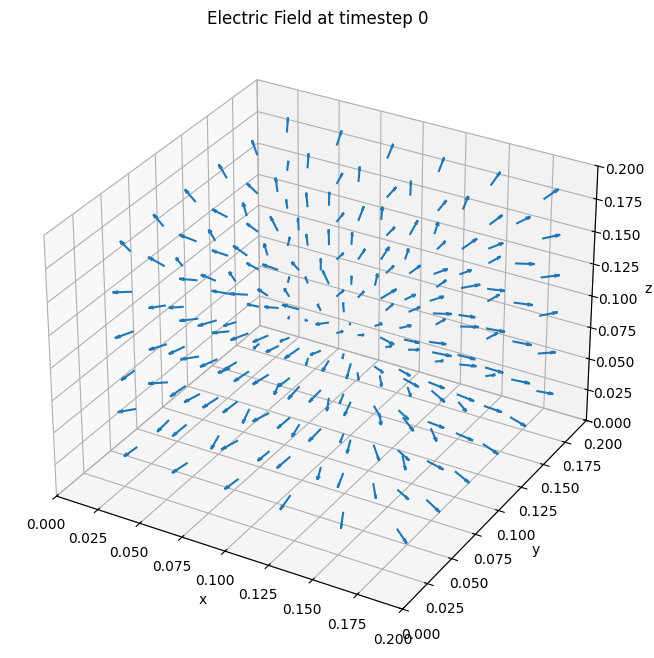

2
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.038661927370642e-22
-3.29418986931008e-22
4.722934850635661e-22
Conservation of Energy
3.0149474150071136e-16
3
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.1171167689900217e-22
-3.2966789042702805e-22
4.92923441727152e-22
Conservation of Energy
3.014947658492692e-16
4
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.235877069893158e-22
-3.0771506554151682e-22
5.003904308964275e-22
Conservation of Energy
3.01494780022626e-16
5
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.2136979810074585e-22
-2.9153279142917735e-22
5.244097577806053e-22
Conservation of Energy
3.014947908988319e-16
6
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.20546559

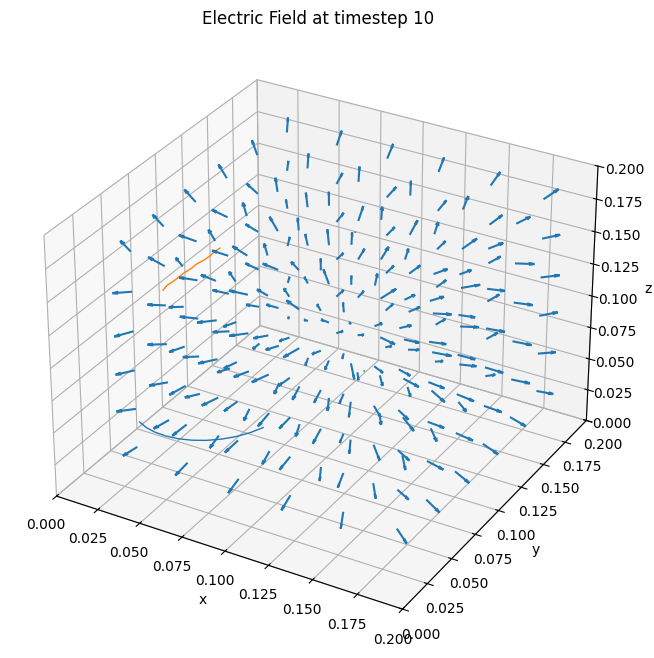

12
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.886856185066782e-22
-1.8991516204764684e-22
5.895861208386189e-22
Conservation of Energy
3.0149483845746815e-16
13
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.7339433169954037e-22
-1.8492275692969595e-22
5.931275076557622e-22
Conservation of Energy
3.014948426443031e-16
14
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.5731689672911887e-22
-1.8511835955227298e-22
6.068725797510767e-22
Conservation of Energy
3.014948460481884e-16
15
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.5529020576033e-22
-1.9128005660217449e-22
6.058513438878654e-22
Conservation of Energy
3.0149484704335096e-16
16
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4731777422358867e-22
-2.

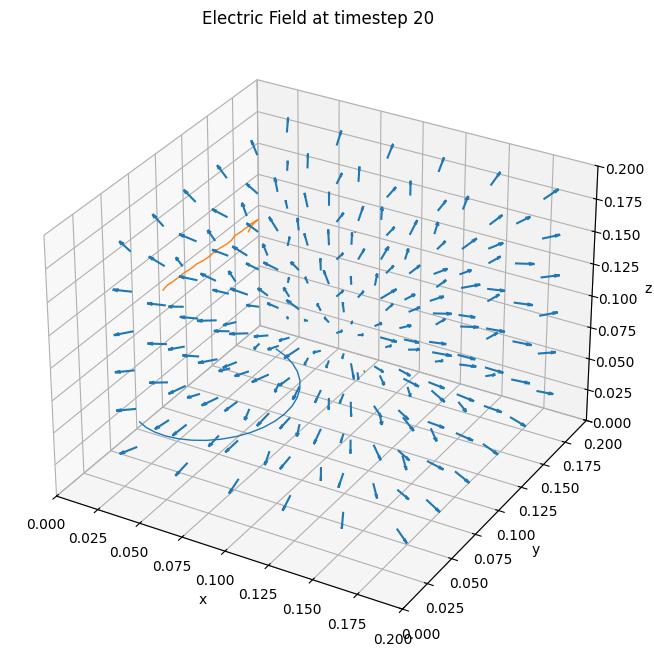

22
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.287950756220495e-22
-2.820894301786534e-22
5.532789472980762e-22
Conservation of Energy
3.0149487899246513e-16
23
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.417809081332889e-22
-3.0303809822352083e-22
5.503764595621794e-22
Conservation of Energy
3.014948795642272e-16
24
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.608974684267354e-22
-3.2625597536444896e-22
5.369656434139043e-22
Conservation of Energy
3.014948812041204e-16
25
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.665957972891004e-22
-3.356340498888386e-22
5.297648020330414e-22
Conservation of Energy
3.014948800945791e-16
26
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.7555207728563895e-22
-3.462

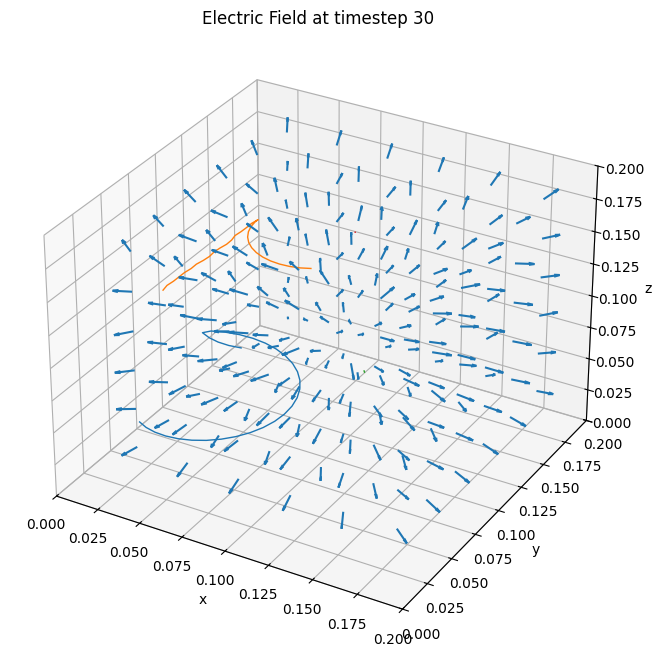

32
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.273711156676704e-22
-4.0257386047680783e-22
4.55982672052619e-22
Conservation of Energy
3.01494871420597e-16
33
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.460434175781025e-22
-3.899118953416198e-22
4.6346593293864645e-22
Conservation of Energy
3.014948700992823e-16
34
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.526266089202864e-22
-4.0496864602182214e-22
4.521735076397525e-22
Conservation of Energy
3.014948680141507e-16
35
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.608614531878295e-22
-4.034089003357289e-22
4.532489503107806e-22
Conservation of Energy
3.0149486638330867e-16
36
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.729588176112593e

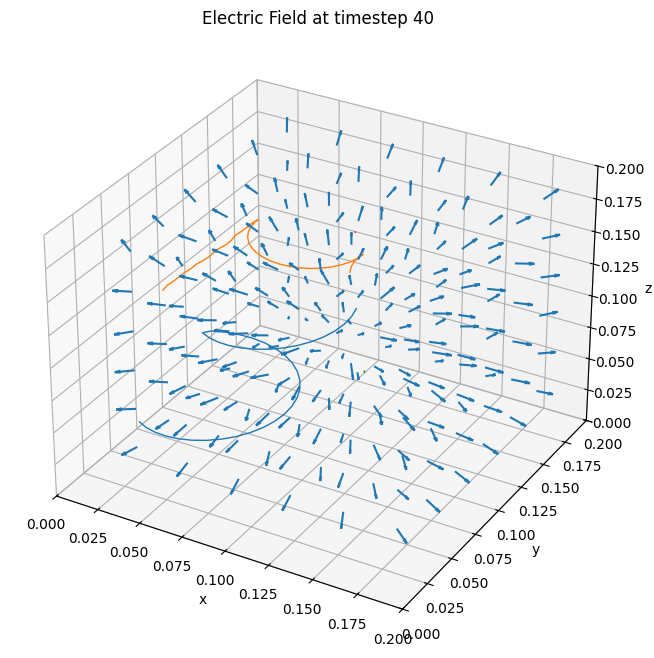

42
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.870283528882423e-22
-3.9806076870021768e-22
4.2986226959892735e-22
Conservation of Energy
3.0149486605565347e-16
43
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.780504154364387e-22
-3.9140493342223656e-22
4.274238925465787e-22
Conservation of Energy
3.014948698502457e-16
44
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.6653120991909245e-22
-3.8929931628371444e-22
4.2163928710320855e-22
Conservation of Energy
3.014948726074201e-16
45
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.639416352449658e-22
-3.8563329672227444e-22
4.1967443426529477e-22
Conservation of Energy
3.0149487075688843e-16
46
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.52211952

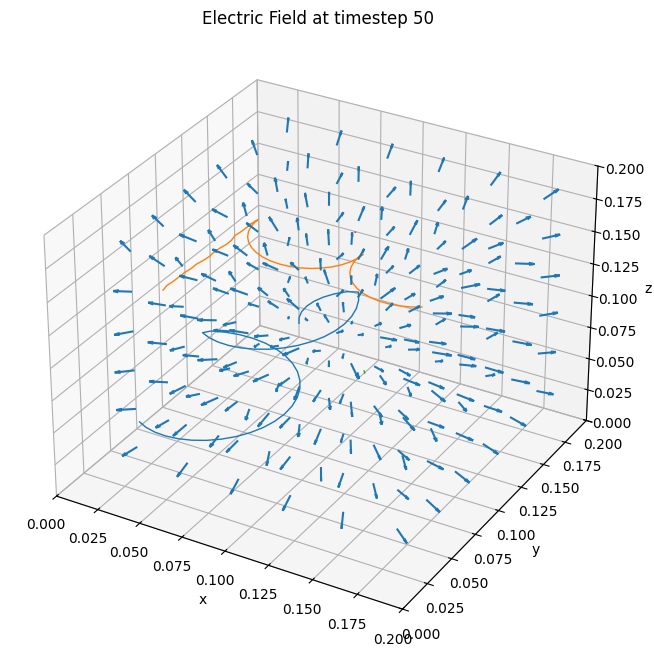

52
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.908499908683415e-22
-3.8175521779354603e-22
4.0807006594044233e-22
Conservation of Energy
3.0149487918252913e-16
53
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.7428214477523188e-22
-3.8931005141643086e-22
3.989009049485257e-22
Conservation of Energy
3.0149487937588885e-16
54
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.6085359409458747e-22
-3.9480829346281266e-22
4.002721157701438e-22
Conservation of Energy
3.0149488212739487e-16
55
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4934905090685393e-22
-4.0454854137286023e-22
3.8718524175001086e-22
Conservation of Energy
3.014948821177088e-16
56
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momen

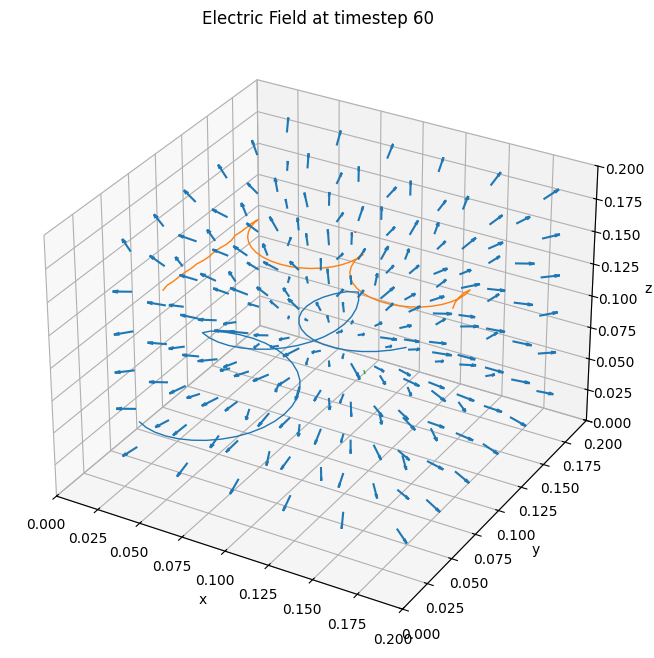

62
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.5119879007989323e-22
-5.197072922084705e-22
4.0620280812892447e-22
Conservation of Energy
3.0149488903690467e-16
63
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.585911285714239e-22
-5.286723948291154e-22
4.06706325018291e-22
Conservation of Energy
3.014948924690284e-16
64
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.6710800542439615e-22
-5.313508423907176e-22
4.053785469771527e-22
Conservation of Energy
3.0149489283567945e-16
65
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.7355862822076756e-22
-5.232381012734966e-22
4.047337446179452e-22
Conservation of Energy
3.0149489290582727e-16
66
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.8309272007407837e-22
-5.

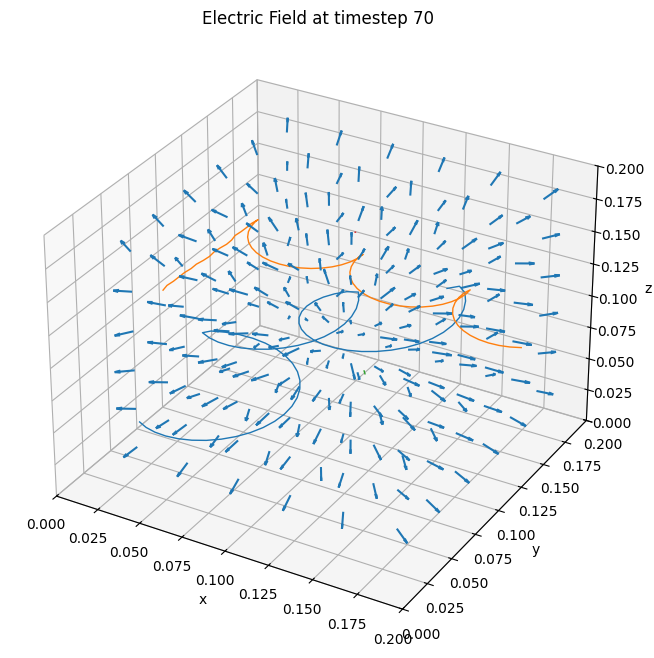

72
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.492197334928514e-22
-5.320691669033872e-22
3.914259849197189e-22
Conservation of Energy
3.0149487837947504e-16
73
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.516642640576795e-22
-5.137005547711166e-22
3.876306431075837e-22
Conservation of Energy
3.014948777247564e-16
74
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.580141196059524e-22
-5.049388194343332e-22
3.8148562839890552e-22
Conservation of Energy
3.014948753215886e-16
75
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.580453307043636e-22
-4.934272047248311e-22
3.8006104540195256e-22
Conservation of Energy
3.0149487353101587e-16
76
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.48478020751253

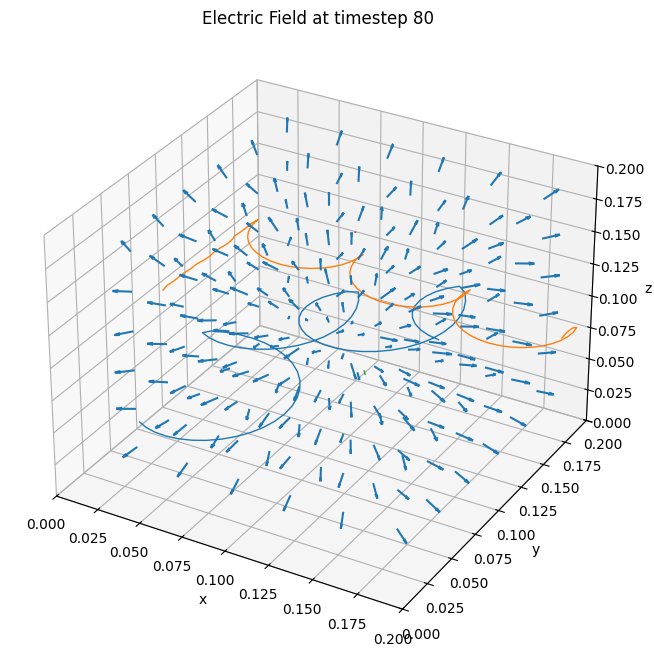

82
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.081180604629846e-22
-4.2344231360181853e-22
3.6852434486958736e-22
Conservation of Energy
3.014948931150368e-16
83
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.9153428003917475e-22
-4.2385741418845885e-22
3.7515112061744926e-22
Conservation of Energy
3.014948948228929e-16
84
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.823947534673504e-22
-4.1779517352511034e-22
3.692784145946316e-22
Conservation of Energy
3.014948952387172e-16
85
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4841092478468774e-22
-4.1205314997069756e-22
3.6458563298854362e-22
Conservation of Energy
3.014948938803497e-16
86
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.374118249

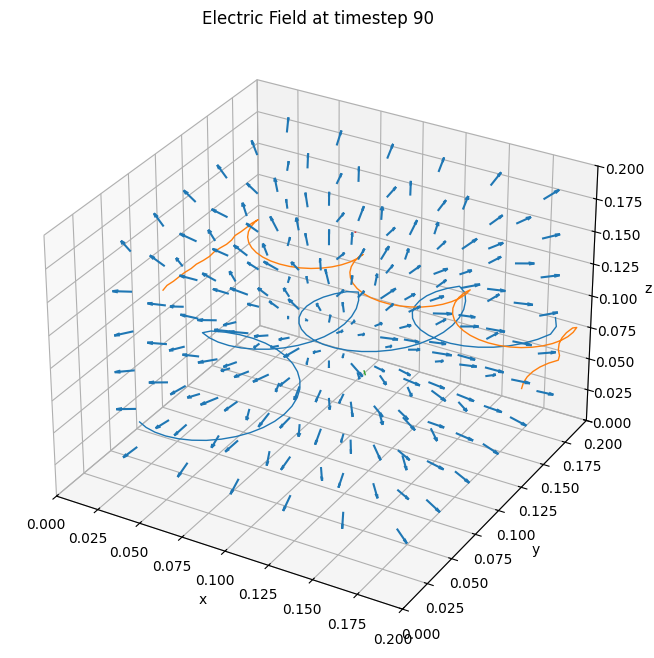

92
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.9272431231673035e-22
-4.462962138406565e-22
3.3502584020218214e-22
Conservation of Energy
3.0149488795624466e-16
93
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.70607489079974e-22
-4.505077669502142e-22
3.3785223768831926e-22
Conservation of Energy
3.0149488557926244e-16
94
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.701039972164144e-22
-4.529378451329652e-22
3.502244230958933e-22
Conservation of Energy
3.014948877083788e-16
95
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.691514628655212e-22
-4.56620380702266e-22
3.4962389467297813e-22
Conservation of Energy
3.014948956353447e-16
96
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.62

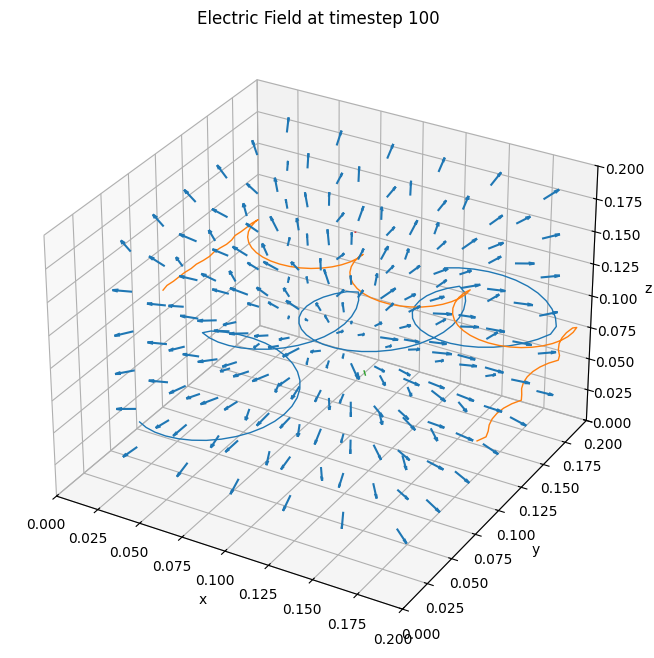

102
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.948845787499879e-22
-5.268707703969003e-22
3.4745029379728504e-22
Conservation of Energy
3.0149488556201754e-16
103
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.1080799860177363e-22
-5.33474684490478e-22
3.421514568070736e-22
Conservation of Energy
3.0149488274202514e-16
104
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.1411770430322322e-22
-5.072367162033487e-22
3.4669188906343676e-22
Conservation of Energy
3.014948835418827e-16
105
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.3770015613243176e-22
-5.101194416696116e-22
3.4960895857138202e-22
Conservation of Energy
3.0149488226421894e-16
106
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Mome

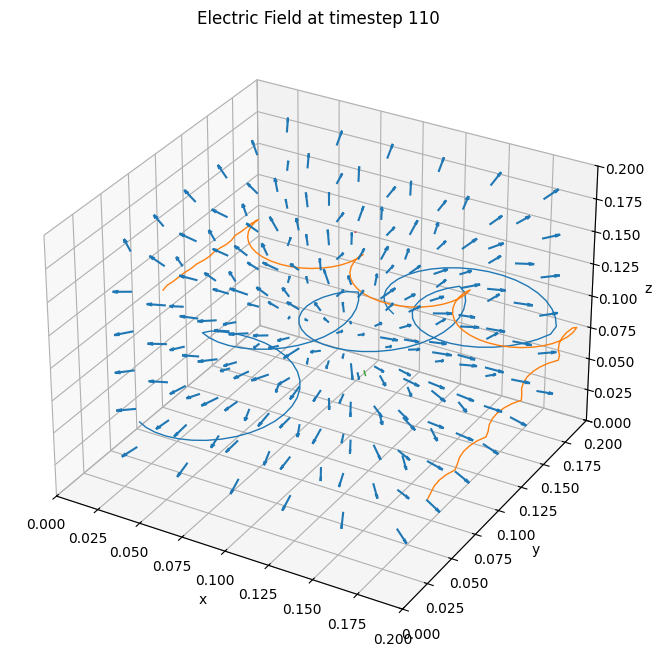

112
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.168918705609517e-22
-4.663971273852162e-22
3.3731722118765453e-22
Conservation of Energy
3.0149489938633894e-16
113
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.087130244649362e-22
-4.540150566494715e-22
3.3898674741933027e-22
Conservation of Energy
3.014949012028983e-16
114
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.024819253397462e-22
-4.415362229939293e-22
3.37506665341283e-22
Conservation of Energy
3.014949003433832e-16
115
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.0675538325716584e-22
-4.473275919440405e-22
3.3403044274475253e-22
Conservation of Energy
3.014948999971626e-16
116
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
4.103662627

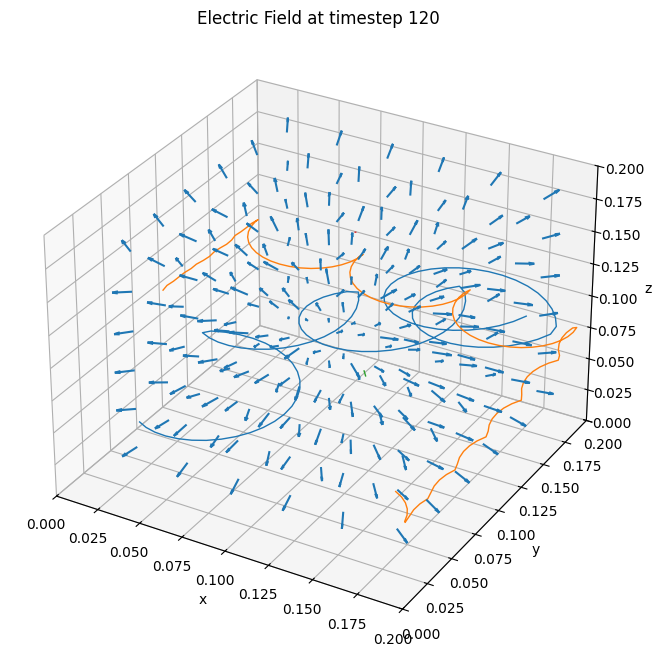

122
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4256543537133853e-22
-3.716496957851624e-22
2.954294876690047e-22
Conservation of Energy
3.014948637012469e-16
123
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.1937688739111284e-22
-3.724182265767318e-22
2.967200963384308e-22
Conservation of Energy
3.0149486539618967e-16
124
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.02437264281492e-22
-3.8033001035003856e-22
2.9852788303980296e-22
Conservation of Energy
3.0149487572056217e-16
125
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.756855063122843e-22
-4.0767843068174464e-22
3.030899662043918e-22
Conservation of Energy
3.014948857468451e-16
126
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.6747210

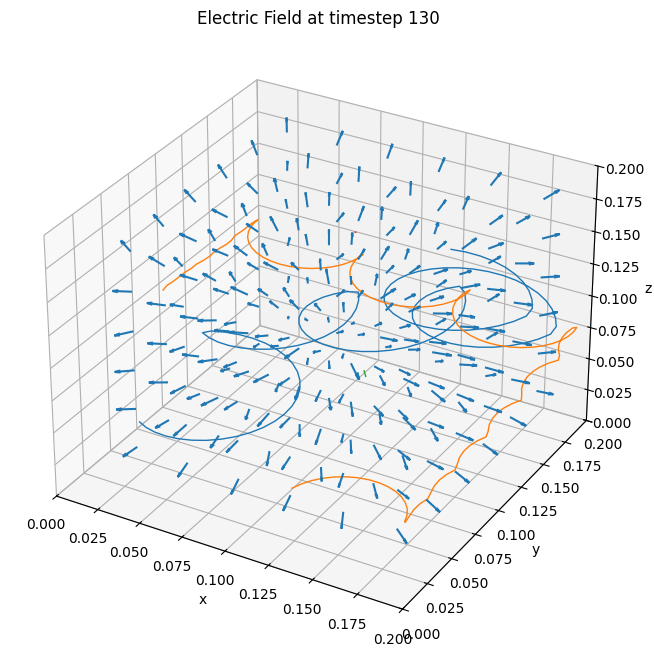

132
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.603693767106001e-22
-4.805086108175448e-22
3.0247610295228624e-22
Conservation of Energy
3.0149490174853125e-16
133
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.669774247739015e-22
-4.86325056091231e-22
3.1192989232619657e-22
Conservation of Energy
3.0149489702469967e-16
134
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.730908491636633e-22
-4.877957475986145e-22
3.200524422163085e-22
Conservation of Energy
3.0149489392661196e-16
135
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
2.7835235985610354e-22
-5.025146639046588e-22
3.157708356408238e-22
Conservation of Energy
3.0149489176117437e-16
136
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Moment

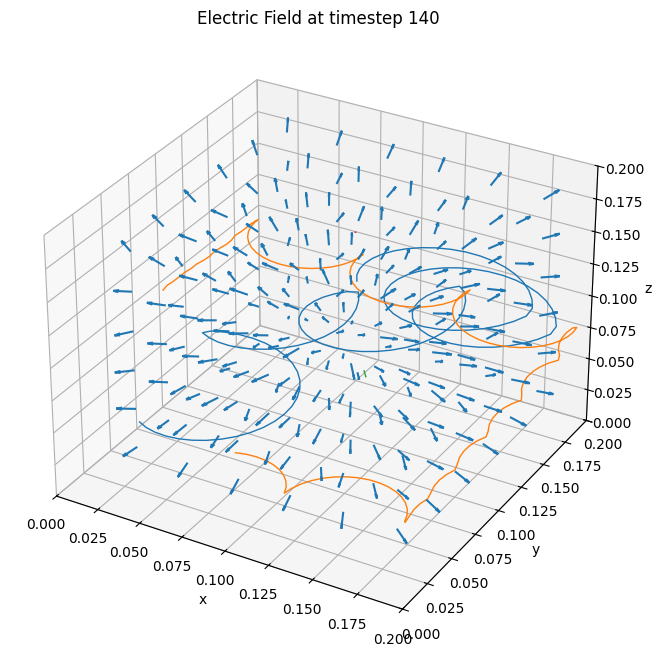

142
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.214972840938228e-22
-5.1225451838836745e-22
3.0156044049612317e-22
Conservation of Energy
3.0149490152597406e-16
143
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.339388802496825e-22
-5.150168721147243e-22
3.089346768722229e-22
Conservation of Energy
3.0149490343989074e-16
144
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.349912138532259e-22
-5.079354084884759e-22
3.111547269011677e-22
Conservation of Energy
3.014949073499071e-16
145
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4011308535044074e-22
-4.972824612190474e-22
3.163623341368673e-22
Conservation of Energy
3.014949088966678e-16
146
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.51012419

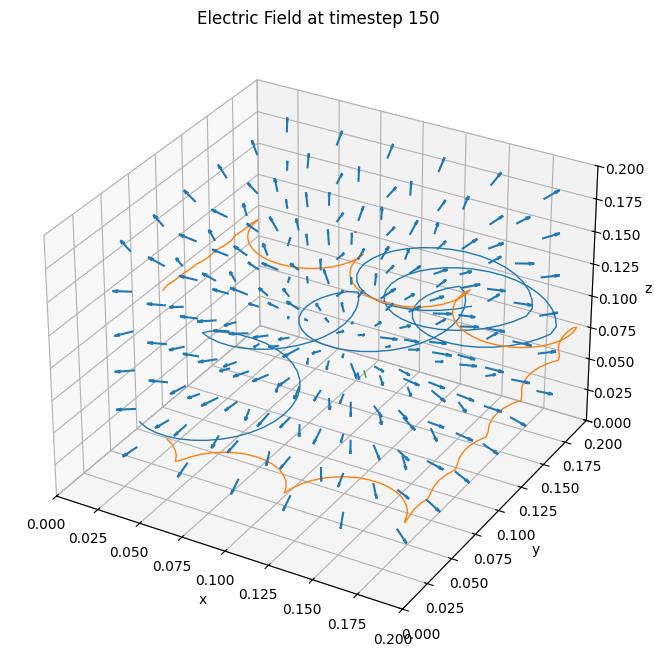

152
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4491156875972183e-22
-4.533752018435706e-22
2.9325585026398985e-22
Conservation of Energy
3.014948865717609e-16
153
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.4201128804185877e-22
-4.385168943678033e-22
2.8362042971448543e-22
Conservation of Energy
3.014948919159702e-16
154
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.3225531875889915e-22
-4.31810844499349e-22
2.8659117187557465e-22
Conservation of Energy
3.014948926675658e-16
155
Conservation of Charge
1.1213999999999996e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.1755667685658027e-22
-4.1857974204052786e-22
2.9006495318409285e-22
Conservation of Energy
3.0149488949848814e-16
156
Conservation of Charge
1.1214e-15
Conservation of Particle Number
1000
8000
Conservation of Momentum
3.0351

KeyboardInterrupt: 

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

#Domain length per dimension
L_x, L_y, L_z = 0.2, 0.2, 0.2

#Ion and electron densities, number, temperatures, mass, and eps0
density_i, density_e = 1e11, 1e11
num_i, num_e = int((0.2*0.2*0.2)*density_i), int((0.1*0.1*0.1)*density_e)
temp_i, temp_e = 0.025, 1 #in eV
m_i, m_e = 1.67e-27, 9.11e-31 #in kg
q_i, q_e = 1.602e-19, -1.602e-19 #in C
eps0 = 8.854e-12 #in Farads per meter

#Introduce macroparticles (don't want to blow up my Chromebook)
Num_e = 1000
Num_i = int((num_i/num_e)*Num_e)

#Number of grid points per dimension
nx, ny, nz = 21, 21, 21

#Spacing per cell
dx, dy, dz = L_x/(nx-1), L_y/(ny-1), L_z/(nz-1)

#Gridspace per dimension
xGrid, yGrid, zGrid = np.linspace(0, L_x, nx), np.linspace(0, L_y, ny), np.linspace(0, L_z, nz)
X, Y, Z = np.meshgrid(L_x, L_y, L_z, indexing='ij')

#Number of iterations and timestep
max_iterations = 1000
dt = 1e-8

#Initial position and speed distribution
pxi = np.random.uniform(0, L_x, Num_i) #x-position for ions
pyi = np.random.uniform(0, L_y, Num_i) #y-position for ions
pzi = np.random.uniform(0, L_z, Num_i) #z-position for ions
pxe = np.random.uniform(0, 0.1, Num_e) #x-position for electrons
pye = np.random.uniform(0, 0.1, Num_e) #y-position for electrons
pze = np.random.uniform(0, 0.1, Num_e) #z-position for electrons
vxi = np.random.normal(0, np.sqrt(temp_i*q_i/m_i), Num_i) #x-velocity for ions
vyi = np.random.normal(0, np.sqrt(temp_i*q_i/m_i), Num_i) #y-velocity for ions
vzi = np.random.normal(0, np.sqrt(temp_i*q_i/m_i), Num_i) #z-velocity for ions
vxe = np.random.normal(0, np.sqrt(temp_e*q_i/m_e), Num_e) #x-velocity for electrons
vye = np.random.normal(0, np.sqrt(temp_e*q_i/m_e), Num_e) #y-velocity for electrons
vze = np.random.normal(0, np.sqrt(temp_e*q_i/m_e), Num_e) #z-velocity for electrons

#External Magnetic Field
B_x, B_y, B_z = 0, 0, 1e-4 #in Teslas

if validateDomain(dx, dy, dz, density_e, temp_e) == False:
  print("Domain size does not satisfy max{dx, dy, dz} < \lambda_D")
  exit()
else:
  print("Valid Domain")

#Initialization
rho = np.zeros((nx, ny, nz))
phiGrid = np.zeros((nx, ny, nz))
EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = np.zeros((nx, ny, nz)), np.zeros((nx, ny, nz)), np.zeros((nx, ny, nz))
EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = np.zeros(Num_e), np.zeros(Num_e), np.zeros(Num_e), np.zeros(Num_i), np.zeros(Num_i), np.zeros(Num_i)

rho = findRhoGrid(dx, dy, dz, nx, ny, nz, pxi, pyi, pzi, pxe, pye, pze, Num_e, Num_i, rho)
phiGrid = findPhiGridMethod1(dx, dy, dz, nx, ny, nz, rho, 1000, 1e-6, phiGrid)
EFieldGrid_x, EFieldGrid_y, EFieldGrid_z = findElectricFieldGrid(dx, dy, dz, nx, ny, nz, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = findElectricFieldParticles(L_x, L_y, L_z, dx, dy, dz, pxi, pyi, pzi, pxe, pye, pze, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, Num_e, Num_i, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i)

#For the sake of plotting particle trajectories
electron_traj_x = []
electron_traj_y = []
electron_traj_z = []
ion_traj_x = []
ion_traj_y = []
ion_traj_z = []

#Forward-Euler timestepper
"""
for t in range(max_iterations):
  pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = timestepMethod1(q_e, q_i, m_e, m_i, Num_e, Num_i, L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, dt)

  electron_traj_x.append(pxe.copy())
  electron_traj_y.append(pye.copy())
  electron_traj_z.append(pze.copy())

  ion_traj_x.append(pxi.copy())
  ion_traj_y.append(pyi.copy())
  ion_traj_z.append(pzi.copy())

  checkConservationLaws(eps0, m_e, m_i, dx, dy, dz, pxe, pxi, vxe, vye, vze, vxi, vyi, vzi, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z)
"""

#Leapfrog timestepper
"""
axe = (q_e/m_e)*(EFieldParticles_x_e + vye*B_z - vze*B_y)
aye = (q_e/m_e)*(EFieldParticles_y_e + vze*B_x - vxe*B_z)
aze = (q_e/m_e)*(EFieldParticles_z_e + vxe*B_y - vye*B_x)
axi = (q_i/m_i)*(EFieldParticles_x_i + vyi*B_z - vzi*B_y)
ayi = (q_i/m_i)*(EFieldParticles_y_i + vzi*B_x - vxi*B_z)
azi = (q_i/m_i)*(EFieldParticles_z_i + vxi*B_y - vyi*B_x)
vxe_half = vxe + 0.5*axe*dt
vye_half = vye + 0.5*aye*dt
vze_half = vze + 0.5*aze*dt
vxi_half = vxi + 0.5*axi*dt
vyi_half = vyi + 0.5*ayi*dt
vzi_half = vzi + 0.5*azi*dt

for t in range(max_iterations):
  pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = timestepMethod2(L_x, L_y, L_z, dx, dy, dz, nx, ny, nz, Num_e, Num_i, pxe, pye, pze, pxi, pyi, pzi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, axe, aye, aze, axi, ayi, azi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, dt)

  electron_traj_x.append(pxe.copy())
  electron_traj_y.append(pye.copy())
  electron_traj_z.append(pze.copy())

  ion_traj_x.append(pxi.copy())
  ion_traj_y.append(pyi.copy())
  ion_traj_z.append(pzi.copy())

  print(t+1)
  checkConservationLaws(eps0, m_e, m_i, dx, dy, dz, pxe, pxi, vxe_half, vye_half, vze_half, vxi_half, vyi_half, vzi_half, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  #animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z)
"""

#Boris Pusher timestepper
for t in range(max_iterations):
  pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i = timestepMethod3(m_e, m_i, q_e, q_i, pxe, pye, pze, pxi, pyi, pzi, vxe, vye, vze, vxi, vyi, vzi, rho, phiGrid, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, EFieldParticles_x_e, EFieldParticles_y_e, EFieldParticles_z_e, EFieldParticles_x_i, EFieldParticles_y_i, EFieldParticles_z_i, B_x, B_y, B_z, dt)

  electron_traj_x.append(pxe.copy())
  electron_traj_y.append(pye.copy())
  electron_traj_z.append(pze.copy())

  ion_traj_x.append(pxi.copy())
  ion_traj_y.append(pyi.copy())
  ion_traj_z.append(pzi.copy())

  print(t+1)
  checkConservationLaws(eps0, m_e, m_i, dx, dy, dz, pxe, pxi, vxe, vye, vze, vxi, vyi, vzi, rho, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z)
  animate(t, L_x, L_y, L_z, EFieldGrid_x, EFieldGrid_y, EFieldGrid_z, electron_traj_x, electron_traj_y, electron_traj_z, ion_traj_x, ion_traj_y, ion_traj_z)


Notes on conservations and consistency checks:
*   **Conservation of Charge:**
*   Conserved beautifully save for some almost unregisterable noise!
*   **Conservation of Particle Number:**
*   Perfect!
*   **Conservation of Momentum:**
*   Not conserved, which is to somewhat expected given the momentum exchange that happens with the boundary. However, there are no blowups, so I presume this is as good as conserved momentum gets. Given this, I'm expecting a lack of conservation of energy.
*   **Conservation of Energy:**
*   No B-Field: Scrub my earlier hypothesis, energy was actually conserved considerably well! It maintained on the order of e-16.
*   With B-Field: Energy was not conserved, it actually increased at a pretty steady rate. Supposedly, this is a known behavior of Forward-Euler.

Numerical Methods Used:
*   Cloud-in-Cell (CIC) weighting (used to calculate charge density at the grid points. A near backwards weighting was done to interpolate the E-field of the particles from the grid points).
*   Second-order central difference formula (used to numerically rewrite the Laplacian in Poisson's equation).
*   Gauss-Seibel iteration (used to further accuracy on our phi as opposed to solving an Ax = b).
*   Forward-Euler timestepping (used to timestep our velocities and positions, and therefore anything that depended on those).
*   Macroparticles (used to represent many particles in one for the sake of computational efficiency).



